In [1]:
# # Run this and then restart the kernel at the start of each session to install
# # 'teotil3' in development mode
# !pip install -e /home/jovyan/projects/teotil3/

In [2]:
import os

import geopandas as gpd
import matplotlib.pyplot as plt
import nivapy3 as nivapy
import pandas as pd
import teotil3 as teo
from tqdm.notebook import tqdm

plt.style.use("ggplot")

In [3]:
eng = nivapy.da.connect_postgis()

Connection successful.


# TEOTIL3 for Lillestrøm kommune
# Notebook 06: Build input files and run model

This notebook takes the standard TEOTIL3 input files, filters them to vassdragsområde 002 (Glomma), and updates them as follows:

 1. The standard spredt data from SSB for regine units within Lillestrøm kommune are replaced with site-specific data provided by Lillestrøm kommune (calculated in notebook 05).
    
 2. Overflows from the wastewater network are included based on data provided by Lillestrøm kommune (notebook 05).

## 1. TEOTIL3 options

The code cell below specifies which of the "standard" TEOTIL3 input files to use as a starting point. 

In [4]:
nve_year = 2024
st_yr, end_yr = 2013, 2023
agri_loss_model = "annual"
output_dir = r"/home/jovyan/shared/common/teotil3/teotil3_lillestrom/annual_input_files"
result_csv = f"/home/jovyan/shared/common/teotil3/teotil3_lillestrom/teotil3_lillestrom_nve{nve_year}_agri-{agri_loss_model}-loss_{st_yr}-{end_yr}.csv"

## 2. Read Lillestrøm-specific data

The code below reads the spredt and overflow estimates created in notebook 05 based on data provided by Lillestrøm kommune.

In [5]:
# Spredt
sp_csv_path = r"../data/lillestrom_regine_spredt.csv"
sp_df = pd.read_csv(sp_csv_path)

ov_csv_path = r"../data/lillestrom_regine_overflows.csv"
ov_df = pd.read_csv(ov_csv_path)

display(sp_df.head())
display(ov_df.head())

,regine,TOTN_kg,TOTP_kg,SS_kg,DIN_kg,TON_kg,TPP_kg,TDP_kg,TOC_kg
0,001.GAA,48.651300,6.558064,164.910375,34.592827,14.058473,2.510308,4.047755,128.860200
1,002.C3,963.766912,114.675716,3080.883750,722.709583,241.057330,48.955535,65.720181,2600.598263
2,002.C5,1665.649575,212.598785,5426.382281,1210.647058,455.002517,84.663617,127.935168,4411.489500
3,002.C7,1067.107095,139.035882,3530.999587,774.781814,292.325281,55.368500,83.667383,2833.872480
4,002.CA3,209.233463,18.909906,612.980812,171.467343,37.766120,9.824851,9.085055,546.258769


,regine,year,TOTN_kg,DIN_kg,TON_kg,TOTP_kg,TDP_kg,TPP_kg,TOC_kg,SS_kg
0,002.C5,2013,0.14325,0.093113,0.050138,0.021487,0.007091,0.014397,0.329475,0.835625
1,002.C5,2014,0.14325,0.093113,0.050138,0.021487,0.007091,0.014397,0.329475,0.835625
2,002.C5,2015,0.14325,0.093113,0.050138,0.021487,0.007091,0.014397,0.329475,0.835625
3,002.C5,2016,0.14325,0.093113,0.050138,0.021487,0.007091,0.014397,0.329475,0.835625
4,002.C5,2017,0.14325,0.093113,0.050138,0.021487,0.007091,0.014397,0.329475,0.835625


## 3. Check regine assignment

Before 2020, Lillestrøm was split into three separate kommuner: Sørum, Fet og Skedsmo (0226, 0227 og 0231). From 2020 onwards these were merged into Lillestrøm (3030). The code below checks that TEOTIL's assignment of regine units to kommuner is the same before and after the merge.

In [6]:
# Get REGINES
reg_gdf = teo.io.get_regine_geodataframe(eng, 2020)
reg_gdf2 = teo.io.get_regine_geodataframe(eng, 2019)

regs1 = set(reg_gdf.query("komnr == '3030'")["regine"].unique())
regs2 = set(reg_gdf2.query("komnr in ('0226', '0227', '0231')")["regine"].unique())
if regs1 == regs2:
    print("TEOTIL3's representation of Lillestrøm kommune is consistent.")
else:
    raise ValueError("Inconsistent assignment of regines before and after 2020.")

TEOTIL3's representation of Lillestrøm kommune is consistent.


## 4. Compare representations of Lillestrøm

In TEOTIL3, regine units are assigned to the kommune with the greatest areal overlap. For example, if 60 % of a regine is within Lillestrøm and 40 % is in the neighbouring kommune, the regine is linked to Lillestrøm. I want to compare the TEOTIL representation of Lillestrøm (i.e. the group of regines linked to Lillestrøm) with the official kommune boundary. I also want to check that the spredt and overflow data provided by Lillestrøm kommune matches TEOTIL3's representation.

In [7]:
# Get official kommune boundary
gpkg_path = (
    r"/home/jovyan/shared/common/teotil3/core_data/administrative/admin_data.gpkg"
)
kom_gdf = gpd.read_file(gpkg_path, layer="kommuner2023").query("komnr == '3030'")

# Get boundary based on TEOTIL regines
teo_kom_gdf = reg_gdf.query("komnr == '3030'").copy()

# Get regines for which Lillestrøm has provided overflow data
ov_reg_list = ov_df["regine"].unique().tolist()
ov_kom_gdf = reg_gdf.query("regine in @ov_reg_list").copy()

# Get regines for which Lillestrøm has provided spredt data
sp_reg_list = sp_df["regine"].unique().tolist()
sp_kom_gdf = reg_gdf.query("regine in @sp_reg_list").copy()

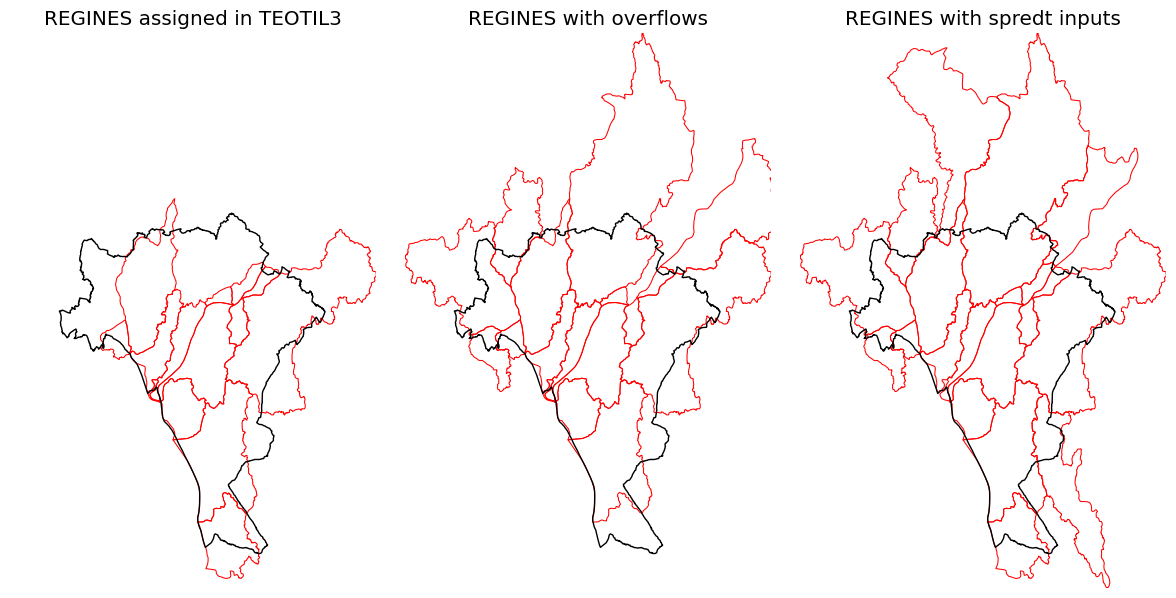

In [8]:
# Maps
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 6))

axes[0].set_title("REGINES assigned in TEOTIL3")
teo_kom_gdf.plot(ax=axes[0], facecolor="none", edgecolor="r", lw=0.75)
kom_gdf.plot(ax=axes[0], facecolor="none", edgecolor="k", lw=1)

axes[1].set_title("REGINES with overflows")
ov_kom_gdf.plot(ax=axes[1], facecolor="none", edgecolor="r", lw=0.75)
kom_gdf.plot(ax=axes[1], facecolor="none", edgecolor="k", lw=1)

axes[2].set_title("REGINES with spredt inputs")
sp_kom_gdf.plot(ax=axes[2], facecolor="none", edgecolor="r", lw=0.75)
kom_gdf.plot(ax=axes[2], facecolor="none", edgecolor="k", lw=1)

# Fix extents
xmin, ymin, xmax, ymax = sp_kom_gdf.total_bounds
for ax in axes:
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.axis("off")

plt.tight_layout()

The maps above show that:

 1. TEOTIL is working as expected. The regine representation roughly matches the true kommune boundary.
    
 2. There are several regines that cross into Lillestrøm, but most of their area is in a neighbouring kommune. In TEOTIL, these are assigned to other kommuner, but Lillestrøm has provided spredt and overflow data for the part of the regine within Lillestrøm.

For the TEOTIL modelling, I will:

 1. Remove any SSB spredt data for the regines linked to TEOTIL (left map above).
    
 2. Also remove any SSB spredt data for regines with site-specific spredt data from Lillestrøm (right map above).

 3. Add the spredt and overflow data from Lillestrøm.

**Note that this approach will underestimate spredt inputs for regines crossing the boundary of Lillestrøm kommune**. This is because I am removing the SSB data and replacing it with Lillestrøm-specific data that only represents part of the regine area. This inconsistency is one of the downsides of using more detailed spredt data from Lillestrøm.

## 5. Update TEOTIL3 input files

In [9]:
# List of regines with SSB data to remove
teo_lil_regs = teo_kom_gdf["regine"].unique().tolist()

# Loop over annual data
for year in range(st_yr, end_yr + 1):
    # Read original input file
    csv_path = f"/home/jovyan/shared/common/teotil3/annual_input_data/agri_{agri_loss_model}_loss/teotil3_input_data_nve{nve_year}_{year}.csv"
    df = pd.read_csv(csv_path)

    # Filter to vassom 002 for speed
    df = df[df["regine"].str.startswith("002.")]

    # Get Lillestrøm-specific spredt data
    ann_sp_df = sp_df.copy()
    ann_sp_df.columns = ["regine"] + [
        "spredt_" + col.lower() for col in ann_sp_df.columns if col.endswith("_kg")
    ]

    # Set all SSB spredt values to 0 for regines linked to Lillestrøm
    spredt_cols = [col for col in df.columns if col.startswith("spredt_")]
    mask = df["regine"].isin(teo_lil_regs)
    df.loc[mask, spredt_cols] = 0

    # Update with Lillestrøm-specific spredt values
    ann_sp_idx = ann_sp_df.set_index("regine")
    df = df.set_index("regine")
    df.update(ann_sp_idx[spredt_cols])
    df = df.reset_index()

    # Add overflows
    ann_ov_df = ov_df.query("year == @year").drop(columns=["year"])
    ann_ov_df.columns = ["regine"] + [
        "overflow_" + col.lower() for col in ann_ov_df.columns if col.endswith("_kg")
    ]
    df = pd.merge(df, ann_ov_df, how="left", on="regine")
    ov_cols = [col for col in ann_ov_df if col.startswith("overflow_")]
    df[ov_cols] = df[ov_cols].fillna(0)

    # Save
    csv_path = os.path.join(
        output_dir,
        f"teotil3_input_data_nve{nve_year}_agri-{agri_loss_model}-loss_{year}.csv",
    )
    df.to_csv(csv_path, index=False)

## 6. Run model

The code below runs TEOTIL3 using the updated model input files (i.e. including overflows and site-specific spredt data from Lillestrøm kommune).

In [10]:
# Run TEOTIL3
years = range(st_yr, end_yr + 1)
df_list = []
for year in tqdm(years):
    csv_path = os.path.join(
        output_dir,
        f"teotil3_input_data_nve{nve_year}_agri-{agri_loss_model}-loss_{year}.csv",
    )
    g = teo.model.run_model(
        csv_path,
        id_col="regine",
        next_down_col="regine_down",
        totals_from_subfracs=True,
    )
    res_df = teo.model.model_to_dataframe(
        g, id_col="regine", next_down_col="regine_down"
    )
    res_df["year"] = year
    df_list.append(res_df)

print("Merging...")
mod_df = pd.concat(df_list, axis="rows")

# Save
mod_df.to_csv(result_csv, index=False)

print("Done.")

  0%|          | 0/11 [00:00<?, ?it/s]

Merging...
Done.
